Setup and Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import os

from src.data_loader import (
    load_articles_df, 
    load_links_df, 
    load_paths_df, 
    load_shortest_path_matrix,
    get_article_text
)
from src.feature_extractor import FeatureExtractor
from src.evaluation import calculate_mrr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [5]:
print("Loading data...")
articles_df = load_articles_df()
links_df = load_links_df()
paths_df = load_paths_df()
dist_matrix = load_shortest_path_matrix()

print("\n--- Articles (head) ---")
display(articles_df.head())

print("\n--- Links (head) ---")
display(links_df.head())

print("\n--- Finished Paths (head) ---")
display(paths_df.head())

print(f"\n--- Distance Matrix (shape) ---")
print(dist_matrix.shape)

Loading data...
Loading distance matrix (fixed-width method)...

--- Articles (head) ---


,article_id,article_name
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin
1,Åland,Åland
2,Édouard_Manet,Édouard_Manet
3,Éire,Éire
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts



--- Links (head) ---


,source,target
0,Áedán_mac_Gabráin,Bede
1,Áedán_mac_Gabráin,Columba
2,Áedán_mac_Gabráin,Dál_Riata
3,Áedán_mac_Gabráin,Great_Britain
4,Áedán_mac_Gabráin,Ireland



--- Finished Paths (head) ---


,session_id,timestamp,session_time,path,rating,type
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,NaN
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,NaN



--- Distance Matrix (shape) ---
(4604, 4604)


Data Loading and Initial Analysis

--- Basic Statistics ---
Total articles (nodes): 4604
Total links (edges): 119882
Total finished paths: 51318

--- Path Length Statistics ---
count    51318.000000
mean         6.757434
std          4.680718
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        435.000000
Name: path_length, dtype: float64


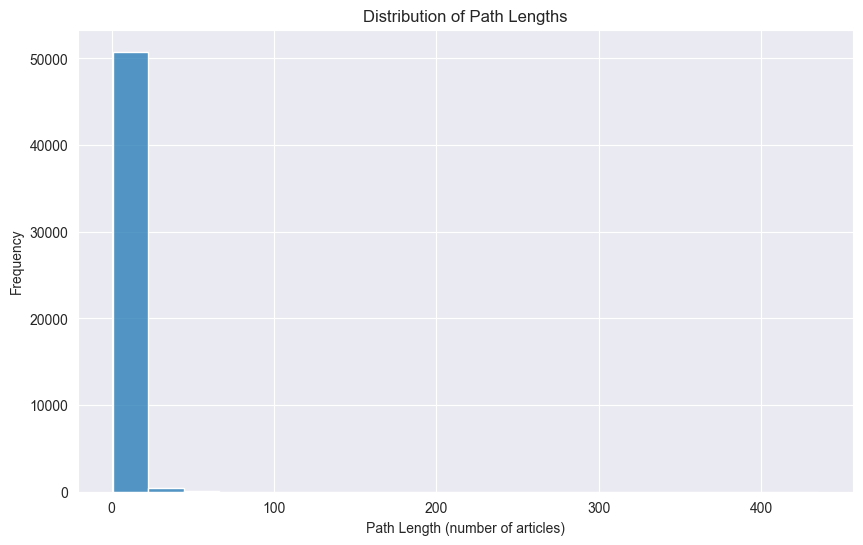


--- Data Integrity Check ---
Articles in 'articles.tsv': 4604
Text files found: 4592
Articles without text files: 418
Example missing text: ['Skåneland', 'The_Last_Supper_(Leonardo)', 'History_of_Miami,_Florida', 'Andrés_Nocioni', 'Robert_Gascoyne-Cecil,_3rd_Marquess_of_Salisbury']


In [6]:
print("--- Basic Statistics ---")
print(f"Total articles (nodes): {len(articles_df)}")
print(f"Total links (edges): {len(links_df)}")
print(f"Total finished paths: {len(paths_df)}")

paths_df['path_length'] = paths_df['path'].apply(lambda x: len(x.split(';')))
print(f"\n--- Path Length Statistics ---")
print(paths_df['path_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(paths_df['path_length'], kde=False, bins=20)
plt.title('Distribution of Path Lengths')
plt.xlabel('Path Length (number of articles)')
plt.ylabel('Frequency')
plt.show()

article_names_with_text = set([f.split('.')[0] for f in os.listdir('./data/plaintext_articles')])
article_names_in_df = set(articles_df['article_name'])
missing_text = article_names_in_df - article_names_with_text

print(f"\n--- Data Integrity Check ---")
print(f"Articles in 'articles.tsv': {len(article_names_in_df)}")
print(f"Text files found: {len(article_names_with_text)}")
print(f"Articles without text files: {len(missing_text)}")
if len(missing_text) > 0:
    print(f"Example missing text: {list(missing_text)[:5]}")

Pre-computation and Setup

In [7]:
extractor = FeatureExtractor()

article_id_to_index = {
    article_id: index 
    for index, article_id in enumerate(articles_df['article_id'])
}

article_id_to_name = pd.Series(
    articles_df.article_name.values, 
    index=articles_df.article_id
).to_dict()

article_name_to_id = pd.Series(
    articles_df.article_id.values,
    index=articles_df.article_name
).to_dict()

links_map = links_df.groupby('source')['target'].apply(list).to_dict()
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

embedding_map = {}
for article_id in tqdm(articles_df['article_id'], desc="Generating Embeddings"):
    article_name = article_id_to_name.get(article_id)
    if article_name:
        text = get_article_text(article_name)
        embedding_map[article_id] = extractor.get_text_embedding(text, strategy='first_para')
    else:
        embedding_map[article_id] = np.zeros(EMBEDDING_DIM)

print("All embeddings are pre-computed and cached.")

Building graph for PageRank and Out-Degree...
Calculating PageRank...
Calculating Out-Degree...
Graph feature maps created.


Generating Embeddings:   0%|          | 0/4604 [00:00<?, ?it/s]

Loading SentenceTransformer model: all-MiniLM-L6-v2...


Generating Embeddings:   0%|          | 1/4604 [00:03<4:29:48,  3.52s/it]

Model loaded successfully.


Generating Embeddings: 100%|██████████| 4604/4604 [00:39<00:00, 117.19it/s]

All embeddings are pre-computed and cached.


### From below #todo - adjust, analyze and fix the code

Data Pipeline: Creating the Feature Dataset

In [ ]:
def create_feature_dataset(
    paths_subset_df, 
    links_map, 
    embedding_map, 
    dist_matrix, 
    article_id_to_index, 
    pagerank_map, 
    out_degree_map, 
    extractor
):
    X_features = []
    y_labels = []
    query_groups = []
    
    for row in tqdm(paths_subset_df.itertuples(), total=len(paths_subset_df), desc="Processing Paths"):
        path_articles = row.path.split(';')
        goal_id = path_articles[-1]

        for i in range(len(path_articles) - 1):
            source_id = path_articles[i]
            positive_target_id = path_articles[i+1]

            query_id = f"{row.Index}_{i}"

            all_candidates = links_map.get(source_id, [])
            if not all_candidates:
                continue

            emb_source = embedding_map.get(source_id, np.zeros(EMBEDDING_DIM))
            emb_goal = embedding_map.get(goal_id, np.zeros(EMBEDDING_DIM))
            source_idx = article_id_to_index.get(source_id, -1)
            goal_idx = article_id_to_index.get(goal_id, -1)
            
            if source_idx == -1 or goal_idx == -1:
                continue

            for candidate_id in all_candidates:
                if candidate_id not in article_id_to_index:
                    continue

                is_positive = 1 if (candidate_id == positive_target_id) else 0

                emb_candidate = embedding_map.get(candidate_id, np.zeros(EMBEDDING_DIM))
                candidate_idx = article_id_to_index.get(candidate_id, -1)

                sem_features = extractor.get_semantic_features(emb_source, emb_candidate, emb_goal)

                path_features = extractor.get_shortest_path_features(source_idx, candidate_idx, goal_idx, dist_matrix)

                topo_features = extractor.get_topology_features(candidate_id, pagerank_map, out_degree_map)

                all_features = {**sem_features, **path_features, **topo_features}

                X_features.append(all_features)
                y_labels.append(is_positive)
                query_groups.append(query_id)

    X_df = pd.DataFrame(X_features)
    y_series = pd.Series(y_labels, name="is_positive")
    query_series = pd.Series(query_groups, name="query_id")
    
    return X_df, y_series, query_series

Splitting Data and Running the Pipeline

In [ ]:
train_paths_df, val_paths_df = train_test_split(
    paths_df, 
    test_size=0.2, 
    random_state=42
)

print(f"Training paths: {len(train_paths_df)}")
print(f"Validation paths: {len(val_paths_df)}")

print("\nGenerating training data...")
X_train_df, y_train, q_train = create_feature_dataset(
    train_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\nGenerating validation data...")
X_val_df, y_val, q_val = create_feature_dataset(
    val_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\n--- Feature Dataset Shapes ---")
print(f"X_train: {X_train_df.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val_df.shape}, y_val: {y_val.shape}")

print("\n--- Example Features ---")
display(X_train_df.head())

print("\n--- Target Distribution (Train) ---")
print(y_train.value_counts(normalize=True))

Model Training

In [ ]:
X_train_df.replace([np.inf, -np.inf], 1000, inplace=True)
X_val_df.replace([np.inf, -np.inf], 1000, inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)

print("Training Proof of Concept model (Logistic Regression)...")
model_poc = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_poc.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'coef': model_poc.coef_[0]
}).sort_values('coef', ascending=False)

print("\n--- Feature Importance (Model Coefficients) ---")
display(feature_importance)

Evaluation

In [ ]:
print("Calculating Mean Reciprocal Rank (MRR) on validation set...")

mrr_score = calculate_mrr(
    model=model_poc,
    X_val=X_val_scaled,
    y_val=y_val,
    query_groups=q_val
)

print("\n" + "="*30)
print(f"   Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
print("="*30)

### TODO Create results summary and define next steps for P3 Milestone